# Setting a chromatin threshold that actually cuts the candidate list

`tp_fp_chromatin_and_raw_score_distribution.ipynb` shows the chromatin density of true and false
positives overlapping heavily. `tp_fp_separability.ipynb` measures the same signal at AUC
0.928–0.996. **Both are right**, and §1 shows why in one line — which is also what makes the
threshold question answerable.

The question here is narrow and practical: *given a new slide and no labels, where do you put the
chromatin cut, and what does it buy?*

Everything runs off `.cache_tail/tp_fp_candidate_features.csv` — the 200,861 candidates
`tp_fp_feature_extract.py` produced from the committed search (`hematoxylin_od`, `cv2.TM_CCOEFF`,
largest-CC template tightening, distance NMS), whose candidate counts reproduce
`results/f1_seed_sweep.csv` exactly. Provenance, feature selection and normalisation are
established there and not repeated. Seconds to run.

**One precondition.** The `od` values here are computed against the **border-padded** channel.
The notebook that prompted this question documents the bug in the unpadded version — 669 of
`301.tiff`'s 25,449 candidates silently get `NaN` chromatin density — and `tp_fp_feature_extract.py`
asserts zero NaNs after padding. Every threshold below is only valid for a pipeline carrying that
fix.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from midog_utils import evaluate as ev

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)

cand = pd.read_csv('.cache_tail/tp_fp_candidate_features.csv')
op = cand[cand.z >= 1.0].copy().reset_index(drop=True)      # the committed operating point
op['y'] = (op.bucket == ev.HUMAN_CORRECT_LABEL).astype(int)
ROIS = list(op.file_name.unique())
DOM = op.groupby('file_name').tumor_type.first()

print(f'{len(op):,} candidates at z >= 1.0 across {len(ROIS)} domain ROIs, '
      f'{int(op.y.sum())} mitotic (base rate {op.y.mean():.3%})')

160,562 candidates at z >= 1.0 across 7 domain ROIs, 902 mitotic (base rate 0.562%)


## 1. The overlap and the AUC are the same fact

A strip plot of ~20,000 false positives against ~200 true positives shows the *extremes*. An AUC
reports the *median*. At a 200:1 imbalance those two readings look completely different.

In [2]:
rows = []
for fn, s in op.groupby('file_name', sort=False):
    v, y = s.od51.to_numpy(), s.y.to_numpy().astype(bool)
    rows.append({
        'file': fn, 'domain': DOM[fn][:24], 'n_FP': int((~y).sum()), 'n_mitotic': int(y.sum()),
        'FP above the MEDIAN mitosis': f'{(v[~y] > np.median(v[y])).sum():,} '
                                       f'({(v[~y] > np.median(v[y])).mean():.1%})',
        'FP above the WEAKEST mitosis': f'{(v[~y] > v[y].min()).sum():,} '
                                        f'({(v[~y] > v[y].min()).mean():.1%})'})
print(pd.DataFrame(rows).to_string(index=False))

    file                   domain  n_FP  n_mitotic FP above the MEDIAN mitosis FP above the WEAKEST mitosis
301.tiff canine cutaneous mast ce 22010        217                   97 (0.4%)               16,996 (77.2%)
201.tiff       canine lung cancer 16512         17                   18 (0.1%)                   784 (4.7%)
246.tiff     canine lymphosarcoma 26562        115                  118 (0.4%)               16,560 (62.3%)
459.tiff canine soft tissue sarco 20762        130                   64 (0.3%)               19,415 (93.5%)
094.tiff      human breast cancer 26066         81                   51 (0.2%)                8,440 (32.4%)
548.tiff           human melanoma 20572        238                   87 (0.4%)               16,933 (82.3%)
402.tiff human neuroendocrine tum 27176        104                  144 (0.5%)                6,381 (23.5%)


On `301.tiff`: **0.4% of false positives beat the median mitosis, and 77.2% beat the weakest one.**

The first number is the AUC talking; the second is what the scatter plot draws. Neither is wrong.
The distributions are well separated in bulk and almost fully overlapping in the tail — and the
tail is where a threshold has to live if you want to keep every mitosis.

That immediately tells you the shape of the answer: **a chromatin threshold can cut a lot of the
list, but only if you accept losing some mitoses.** The rest of this notebook prices that trade.

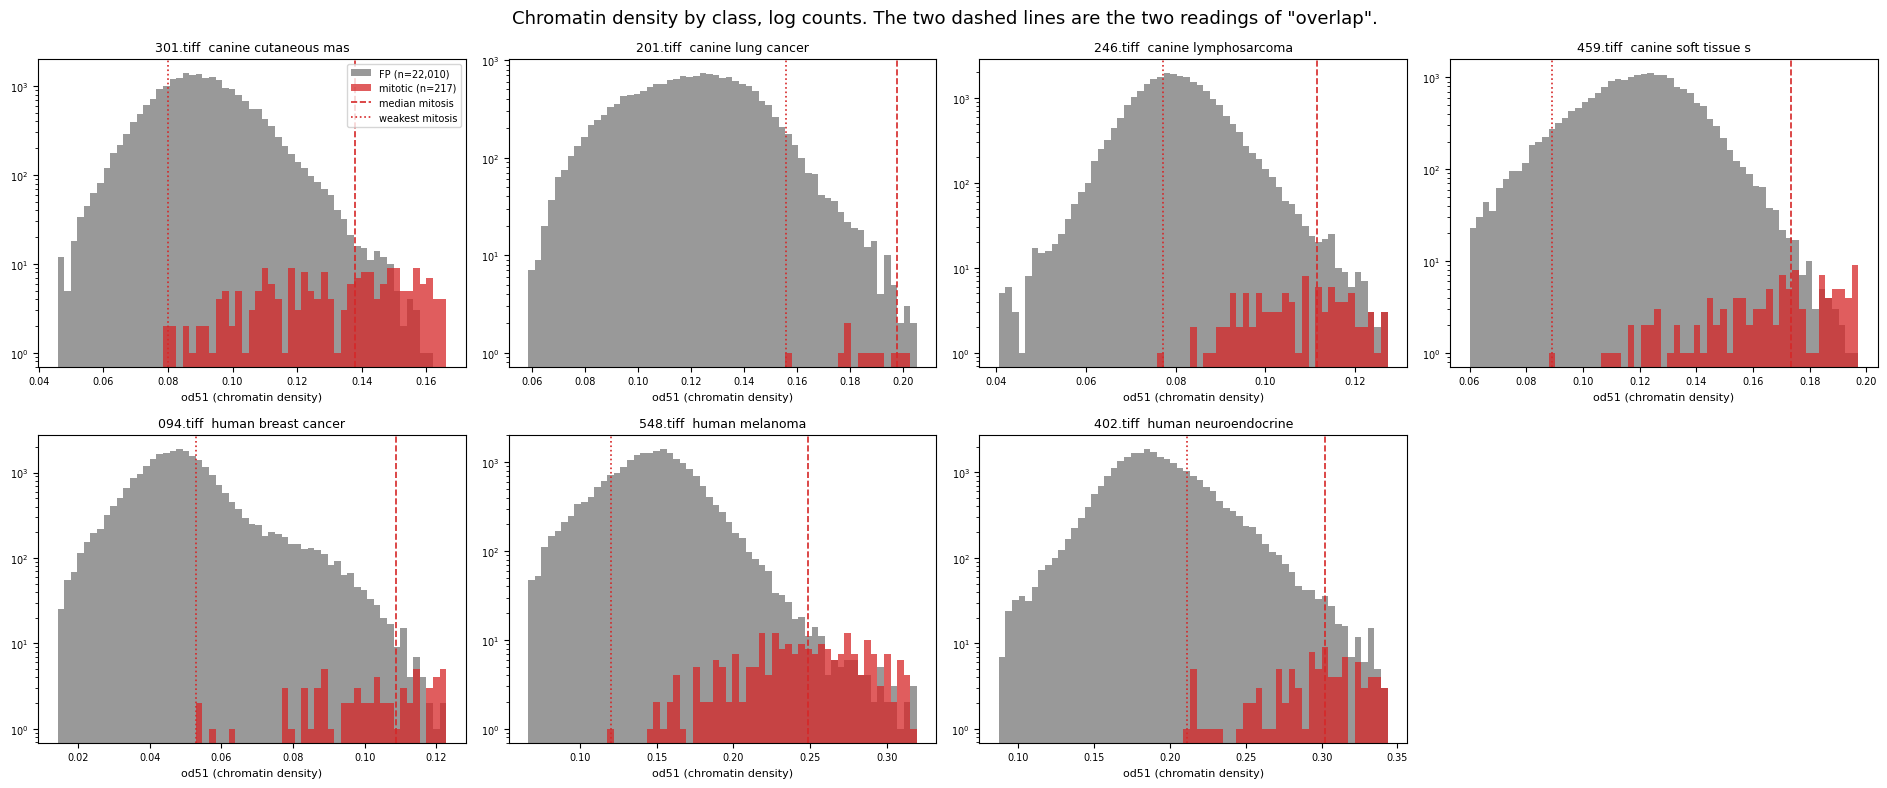

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
for ax, (fn, s) in zip(axes.ravel(), op.groupby('file_name', sort=False)):
    v, y = s.od51.to_numpy(), s.y.to_numpy().astype(bool)
    bins = np.linspace(np.quantile(v, 0.001), np.quantile(v, 0.999), 60)
    ax.hist(v[~y], bins=bins, color='0.6', label=f'FP (n={int((~y).sum()):,})')
    ax.hist(v[y], bins=bins, color='tab:red', alpha=0.75, label=f'mitotic (n={int(y.sum())})')
    ax.axvline(np.median(v[y]), color='tab:red', ls='--', lw=1.2, label='median mitosis')
    ax.axvline(v[y].min(), color='tab:red', ls=':', lw=1.2, label='weakest mitosis')
    ax.set_yscale('log')
    ax.set_title(f'{fn}  {DOM[fn][:20]}', fontsize=9)
    ax.set_xlabel('od51 (chromatin density)', fontsize=8); ax.tick_params(labelsize=7)
axes.ravel()[0].legend(fontsize=7)
axes.ravel()[-1].axis('off')
fig.suptitle('Chromatin density by class, log counts. The two dashed lines are the two readings '
             'of "overlap".', fontsize=13)
fig.tight_layout(); plt.show()

## 2. What a threshold can buy, if you knew the answer in advance

The oracle version first: for each ROI, the smallest top-`q`% of its own candidates by chromatin
density that still contains a given fraction of its mitoses. No rule could ever beat this, because
it is set with the labels in hand.

In [4]:
TARGETS = (1.00, 0.98, 0.95, 0.90, 0.80, 0.70)


def oracle_q(sub, key, target):
    '''Smallest fraction of this ROI's pool that still holds `target` of its mitoses.'''
    v, y = sub[key].to_numpy(), sub.y.to_numpy().astype(bool)
    thr = np.quantile(v[y], 1 - target) if target < 1 else v[y].min()
    return float((v >= thr).mean())


for key in ('od51', 'od_contrast'):
    t = pd.DataFrame([{'file': fn, 'domain': DOM[fn][:22], 'n_cand': int((op.file_name == fn).sum()),
                       **{f'{tg:.0%}': f'{100 * oracle_q(op[op.file_name == fn], key, tg):.1f}%'
                          for tg in TARGETS}} for fn in ROIS])
    print(f'=== {key}: fraction of the pool you must keep to retain N% of mitoses (oracle) ===')
    print(t.to_string(index=False))
    print()

=== od51: fraction of the pool you must keep to retain N% of mitoses (oracle) ===
    file                 domain  n_cand  100%   98%   95%   90%  80%  70%
301.tiff canine cutaneous mast    22227 77.4% 64.0% 38.4% 22.7% 9.3% 4.2%
201.tiff     canine lung cancer   16529  4.8%  2.8%  1.3%  0.8% 0.7% 0.5%
246.tiff   canine lymphosarcoma   26677 62.5% 25.7% 13.2%  7.7% 3.4% 1.7%
459.tiff canine soft tissue sar   20892 93.6% 68.1% 47.2% 27.0% 5.6% 2.1%
094.tiff    human breast cancer   26147 32.6% 25.0%  6.0%  4.2% 2.6% 1.2%
548.tiff         human melanoma   20810 82.5% 37.1% 17.4%  8.1% 3.0% 1.8%
402.tiff human neuroendocrine t   27280 23.8% 21.0% 19.6%  5.9% 2.3% 1.5%



=== od_contrast: fraction of the pool you must keep to retain N% of mitoses (oracle) ===
    file                 domain  n_cand  100%   98%   95%   90%  80%  70%
301.tiff canine cutaneous mast    22227 80.9% 53.4% 32.8% 16.6% 5.7% 2.7%
201.tiff     canine lung cancer   16529  2.5%  1.7%  1.1%  0.8% 0.6% 0.5%
246.tiff   canine lymphosarcoma   26677 38.9% 17.5% 11.6%  6.7% 3.3% 1.6%
459.tiff canine soft tissue sar   20892 94.8% 70.5% 40.9% 19.2% 4.7% 1.9%
094.tiff    human breast cancer   26147 38.5% 27.7%  6.1%  4.8% 2.7% 1.0%
548.tiff         human melanoma   20810 82.0% 29.5% 16.1%  6.5% 2.4% 1.6%
402.tiff human neuroendocrine t   27280 18.3% 11.2% 10.6%  3.8% 1.7% 1.0%



Read the `100%` column first: to keep **every** mitosis you must retain 5%–94% of the pool, median
~63%. **No chromatin threshold gives you a short list at full sensitivity** — that is the same
convex tail `results/tail_sensitivity.csv` has measured from three other directions.

Now read across. Give up 5% of the mitoses and the median retention drops to ~12–17%; give up 10%
and it drops to ~7%. **Almost all of the achievable cut is bought with the first 5–10% of
sensitivity.**

The other thing this table says is a warning: the required `q` at 95% recall runs from **1.1% on
`201.tiff` to 40.9% on `459.tiff`** — a 37x spread. Any single fixed rule will be wrong somewhere,
and §3 measures how wrong.

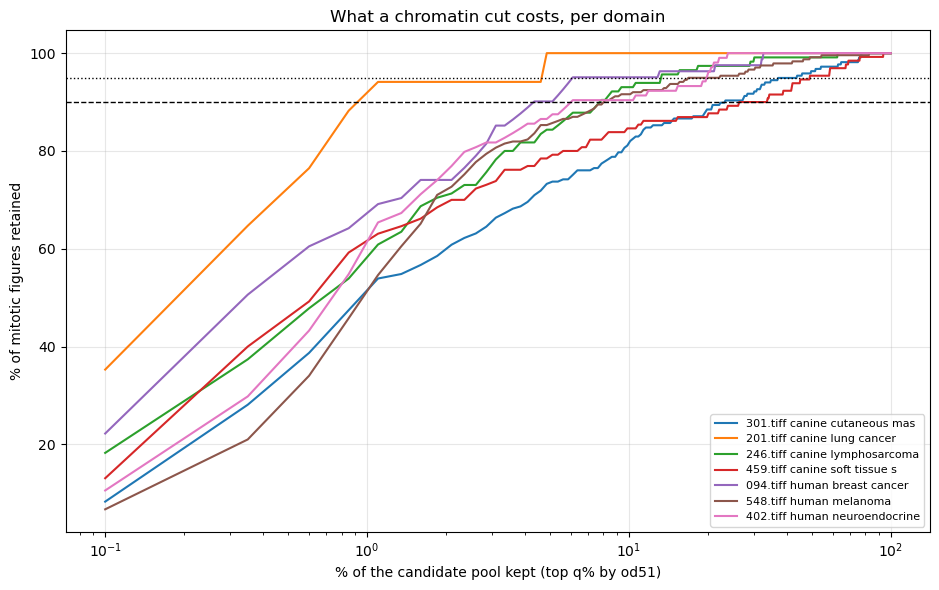

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 6))
grid = np.linspace(0.001, 1.0, 400)
for fn in ROIS:
    s = op[op.file_name == fn]
    v, y = s.od51.to_numpy(), s.y.to_numpy().astype(bool)
    thr = np.quantile(v, 1 - grid)
    rec = [(v[y] >= t).mean() for t in thr]
    ax.plot(100 * grid, 100 * np.array(rec), label=f'{fn} {DOM[fn][:20]}')
ax.axhline(95, color='k', ls=':', lw=1)
ax.axhline(90, color='k', ls='--', lw=1)
ax.set_xscale('log')
ax.set_xlabel('% of the candidate pool kept (top q% by od51)')
ax.set_ylabel('% of mitotic figures retained')
ax.set_title('What a chromatin cut costs, per domain')
ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='lower right')
fig.tight_layout(); plt.show()

## 3. The unit you set the threshold in decides whether it transfers

On a new slide you have no labels, so the threshold has to come from somewhere else. Three
candidate units, each fitted on six ROIs and applied to the seventh:

* **absolute** — a fixed `od` value.
* **quantile** — "keep the top q% of this ROI's own candidates".
* **robust z** — `median(od) + k * MAD(od)` within the ROI's own pool.

`chromatin.py` states that optical density *"is not calibrated across scanners"*, so the absolute
rule is expected to fail. It is included so the failure is measured rather than asserted.

In [6]:
def params_for(sub, key, target):
    '''The same oracle threshold expressed in all three units.'''
    v, y = sub[key].to_numpy(), sub.y.to_numpy().astype(bool)
    thr = np.quantile(v[y], 1 - target) if target < 1 else v[y].min()
    med = np.median(v)
    mad = 1.4826 * np.median(np.abs(v - med))
    return {'absolute': float(thr), 'quantile': float((v >= thr).mean()),
            'robustz': float((thr - med) / mad) if mad > 0 else np.nan}


def apply_rule(sub, key, unit, param):
    v = sub[key].to_numpy()
    if unit == 'absolute':
        thr = param
    elif unit == 'quantile':
        thr = np.quantile(v, 1 - param)
    else:
        med = np.median(v)
        thr = med + param * 1.4826 * np.median(np.abs(v - med))
    keep = v >= thr
    return float(keep.mean()), float(sub.y.to_numpy()[keep].sum() / sub.y.sum())


out = []
for key in ('od51', 'od_contrast'):
    for target in (0.95, 0.90, 0.80):
        for unit in ('absolute', 'quantile', 'robustz'):
            recs, keeps = [], []
            for held in ROIS:
                param = float(np.median([params_for(op[op.file_name == f], key, target)[unit]
                                         for f in ROIS if f != held]))
                k, r = apply_rule(op[op.file_name == held], key, unit, param)
                keeps.append(k); recs.append(r)
            out.append({'key': key, 'target recall': f'{target:.0%}', 'unit': unit,
                        'median recall': f'{np.median(recs):.1%}',
                        'WORST recall': f'{min(recs):.1%}',
                        'median cut': f'{1 - np.median(keeps):.0%}',
                        'worst cut': f'{1 - max(keeps):.0%}'})
transfer = pd.DataFrame(out)
print('leave-one-domain-out: parameter set on six ROIs, applied to the seventh\n')
print(transfer.to_string(index=False))

leave-one-domain-out: parameter set on six ROIs, applied to the seventh

        key target recall     unit median recall WORST recall median cut worst cut
       od51           95% absolute         88.5%         0.0%        77%        1%
       od51           95% quantile         94.5%        86.6%        84%       82%
       od51           95%  robustz         93.3%        86.2%        84%       81%
       od51           90% absolute         86.2%         0.0%        87%        1%
       od51           90% quantile         87.8%        76.0%        93%       92%
       od51           90%  robustz         87.0%        74.2%        94%       88%
       od51           80% absolute         81.5%         0.0%        93%        2%
       od51           80% quantile         79.8%        64.5%        97%       97%
       od51           80%  robustz         79.8%        63.8%        97%       93%
od_contrast           95% absolute         88.5%        45.2%        85%       37%
od_contrast   

**The absolute threshold fails, and it fails all the way to zero.** Worst-case realized recall is
**0.0%** for `od51` — on at least one held-out domain, a fixed `od` value carried over from the
other six excludes every mitotic figure. This is `chromatin.py`'s uncalibrated-across-scanners
warning, measured. *Never ship an absolute chromatin threshold.*

**Quantile transfers best**, slightly ahead of robust-z at every target. That is worth stating
plainly: the deployable form of "set a chromatin threshold" is **"keep the top q% of this ROI's own
candidates by chromatin density"** — a rule that reads the new slide's own distribution and needs
no calibration.

**`od_contrast` beats `od51`** at every target in both realized recall and cut, which matches its
higher AUC (0.937–0.997 vs 0.928–0.996) in `tp_fp_separability.ipynb`. It costs one extra window
read per candidate.

## 4. The rule, and what it actually does

`od_contrast`, quantile unit, tuned for 95% recall on the six ROIs the held-out one is not in.

In [7]:
rows = []
for held in ROIS:
    q = float(np.median([params_for(op[op.file_name == f], 'od_contrast', 0.95)['quantile']
                         for f in ROIS if f != held]))
    s = op[op.file_name == held]
    v = s.od_contrast.to_numpy()
    keep = v >= np.quantile(v, 1 - q)
    rows.append({'held-out ROI': held, 'domain': DOM[held][:22], 'q from the other 6': f'{100 * q:.1f}%',
                 'candidates before': len(s), 'after': int(keep.sum()), 'cut': f'{1 - keep.mean():.0%}',
                 'mitoses kept': f'{int(s.y.to_numpy()[keep].sum())}/{int(s.y.sum())}',
                 'recall': f'{s.y.to_numpy()[keep].sum() / s.y.sum():.1%}'})
rule = pd.DataFrame(rows)
print(rule.to_string(index=False))
before = rule['candidates before'].sum(); after = rule['after'].sum()
print(f'\npooled: {before:,} -> {after:,} candidates, {1 - after / before:.0%} cut')
print(f'recall: median {np.median([float(r[:-1]) for r in rule.recall]):.1f}%, '
      f'worst {min(float(r[:-1]) for r in rule.recall):.1f}%')
rule.to_csv('results/chromatin_threshold_rule.csv', index=False)
transfer.to_csv('results/chromatin_threshold_transfer.csv', index=False)

held-out ROI                 domain q from the other 6  candidates before  after cut mitoses kept recall
    301.tiff canine cutaneous mast               11.1%              22227   2465 89%      188/217  86.6%
    201.tiff     canine lung cancer              13.8%              16529   2289 86%        17/17 100.0%
    246.tiff   canine lymphosarcoma              13.3%              26677   3558 87%      111/115  96.5%
    459.tiff canine soft tissue sar              11.1%              20892   2317 89%      114/130  87.7%
    094.tiff    human breast cancer              13.8%              26147   3621 86%        78/81  96.3%
    548.tiff         human melanoma              11.1%              20810   2308 89%      222/238  93.3%
    402.tiff human neuroendocrine t              13.8%              27280   3778 86%      102/104  98.1%

pooled: 160,562 -> 20,336 candidates, 87% cut
recall: median 96.3%, worst 86.6%


## 5. The answer

**Keep the top ~12% of each ROI's own candidates by `od_contrast` (or `od51`).** Leave-one-domain-out,
that cuts **87% of the candidate list** — 160,562 candidates down to 20,336 — at a **median recall
of 96.3%**, worst domain **86.6%**.

Concretely, on `301.tiff`: **22,227 candidates become 2,465, and 188 of 217 mitotic figures
survive.**

Three things to be clear-eyed about before adopting it:

**1. It costs mitoses, and it costs the most where mitoses are densest.** The two worst domains are
`301.tiff` (86.6%) and `459.tiff` (87.7%) — the two that needed the largest oracle `q`. A rule
tuned on other domains under-serves exactly the slides with the most to find. If a domain's
mitotic count is what the report turns on, that is the wrong place to lose 13%.

**2. There is no threshold that keeps everything.** §2's `100%` column requires retaining 5–94% of
the pool. If the requirement is genuinely "cover the entire mitotic population", a chromatin
threshold is not the instrument, and `Research Logs/2026-09-03-fp-reduction-framing.md` §3 already
argues the requirement itself is the thing to revisit.

**3. This threshold is not a new lever — it is where you stop reading.** The pipeline already
re-ranks by chromatin density, so "keep the top q% by `od`" and "read the top `q·N` of the
chromatin-ranked list" are the same operation. The threshold does not add information; it converts
a ranking into a shorter list by accepting a recall loss. **What §3 does add is the unit**: the cut
must be a per-ROI quantile, never an absolute `od` value, and that distinction is worth 0–100% of
your recall.

**If the goal is finding mitoses sooner rather than a shorter list**, the better lever is already
measured: the leave-one-domain-out re-rank in `tp_fp_separability.ipynb` §9 cuts `read_95` to
0.13x–0.29x on four of seven domains without discarding anything.

## 6. Limits

- **One seed per ROI**, `seed_index = 0`. The pool composition is seed-dependent; `q` is a property
  of the pool, so a seed sweep would put an error bar on the recommended value. Not run.
- **Seven ROIs, one per domain.** The recommended `q` is a median over six numbers spanning
  1.1%–40.9%. That spread is the honest uncertainty on the rule, and it is large.
- **Recall here is of the mitoses the search captured**, which is 100% of ground truth at the deep
  floor in all seven ROIs (`results/tp_fp_extract_summary.csv`), so it is also recall of ground
  truth at `z >= 1.0`.
- **`od_contrast` needs a second window read** (121 px) per candidate. Measured cost in
  `tp_fp_feature_extract.py` is a few seconds per ROI, but it is not free.
- **Only valid with the padded-channel chromatin fix** (see the header).